In [19]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models, layers, callbacks, utils
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from collections import Counter

In [20]:
df=pd.read_csv("cleaned_ph_updated.csv")
df = df.dropna(subset=['status'])
df.head()

,county,sitename,Date,pm2.5,pm10,no,no2,nox,co,so2,o3,AQI,status
0,NCR,Manila,2014-01-01,42.450712,105.388892,18.993939,68.680839,46.467632,1.180798,23.094493,12.319120,118.0,emergency
1,NCR,Manila,2014-02-01,32.926035,77.352669,22.808572,57.520162,42.574229,0.793464,19.536258,44.687065,95.0,emergency
2,NCR,Manila,2014-03-01,44.715328,99.910623,34.325038,54.807419,47.240203,1.000999,26.546239,26.985845,124.0,emergency
3,NCR,Manila,2014-04-01,57.845448,138.179877,20.041346,80.667124,53.375489,1.428835,34.518627,48.524207,152.0,emergency
4,NCR,Manila,2014-05-01,31.487699,70.390261,22.100780,56.562426,41.691499,1.120790,17.809835,51.075438,92.0,emergency


In [21]:
features = ['so2', 'co', 'o3', 'pm10', 'pm2.5', 'no2', 'nox', 'no']
X = df[features]
y = df['status']

In [22]:
le = LabelEncoder()
y_encoded = le.fit_transform(y.values.ravel())
num_classes = len(le.classes_)
#y_encoded =utils.to_categorical(y_encoded, num_classes=num_classes)

In [23]:
X_train,X_test,y_train,y_test=train_test_split(X,y_encoded,test_size=0.2,shuffle=True)

In [24]:
smote= SMOTE(random_state=42)
X_train_res, y_train_res=smote.fit_resample(X_train,y_train)

In [25]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

In [26]:
model = tf.keras.Sequential([
# Input shape: (Time Steps, Features)
    layers.Input(shape=(8,)), 
    
    
    # first Dense layer
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    # Second Dense layer
    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    # third Dense layer
    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    # third Dense layer
    layers.Dense(32),
    layers.BatchNormalization(),
    layers.Dropout(0.2),


    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])

In [27]:
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=1e-6
)

my_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    callbacks.ModelCheckpoint(filepath='best_model_svm_classifier.keras', monitor='val_accuracy', save_best_only=True),
    reduce_lr
]

In [28]:
model.compile(optimizer=Adam(learning_rate=0.0005), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train_scaled, y_train_res, epochs=100, batch_size=128,validation_split=0.2,callbacks=my_callbacks,shuffle=True)

Epoch 1/100
298/298 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6865 - loss: 0.7852 - val_accuracy: 0.4857 - val_loss: 0.9147 - learning_rate: 5.0000e-04
Epoch 2/100
136/298 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8092 - loss: 0.4740

KeyboardInterrupt: 

In [ ]:
best_model=tf.keras.models.load_model("best_model_svm_classifier.keras")
best_model.build(input_shape=(None,8))


# Reconstruct the feature extractor by defining an explicit input layer
input_layer = layers.Input(shape=(8,))
x = input_layer

for layer in best_model.layers[:-2]: 
    x = layer(x)

feature_extractor = models.Model(inputs=input_layer, outputs=x)


X_train_features = feature_extractor.predict(X_train_scaled)
X_test_features = feature_extractor.predict(X_test_scaled)


f_scaler=StandardScaler()
X_features_train_scaled=f_scaler.fit_transform(X_train_features)
X_features_test_scaled=f_scaler.transform(X_test_features)

# Train SVM on the extracted features
svm_model = LinearSVC(dual=False,class_weight='balanced',max_iter=2000,random_state=42)
svm_model.fit(X_features_train_scaled, y_train_res)

# Evaluate SVM
y_pred_svm = svm_model.predict(X_features_test_scaled)
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

1489/1489 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
                               precision    recall  f1-score   support

            acutely unhealthy       0.98      0.92      0.95      1980
                    emergency       0.93      0.98      0.96       555
                         fair       0.82      0.87      0.85       286
                         good       0.99      0.96      0.98       399
unhealthy for sensitive group       0.76      0.80      0.78       355
               very unhealthy       0.73      0.83      0.77       515

                     accuracy                           0.91      4090
                    macro avg       0.87      0.89      0.88      4090
                 weighted avg       0.91      0.91      0.91      4090



In [30]:
from sklearn.metrics import accuracy_score, precision_score, f1_score,recall_score
from tensorflow.keras.callbacks import EarlyStopping

# Compute global metrics for the SVM model
global_accuracy = accuracy_score(y_test, y_pred_svm)
global_precision = precision_score(y_test, y_pred_svm, average='weighted')
global_f1 = f1_score(y_test, y_pred_svm, average='weighted')
global_recall = recall_score(y_test, y_pred_svm, average='weighted')

print(f"Global Accuracy: {global_accuracy}")
print(f"Global Precision: {global_precision}")
print(f"Global F1-Score: {global_f1}")
print(f"Global Recall: {global_recall}")



Global Accuracy: 0.9058679706601467
Global Precision: 0.9122300450131671
Global F1-Score: 0.9079720306394597
Global Recall: 0.9058679706601467


In [ ]:
import joblib

# Save the SVM model to a file
joblib.dump(svm_model, 'svm_model_classifier.pkl')


['svm_model_classifier.pkl']

In [ ]:
joblib.dump(scaler,'scaler_classifer-.pkl')


['scaler_classifer-.pkl']

In [ ]:
print(list(enumerate(le.classes_)))

[(0, 'Good'), (1, 'Moderate'), (2, 'Unhealthy for Sensitive Groups')]


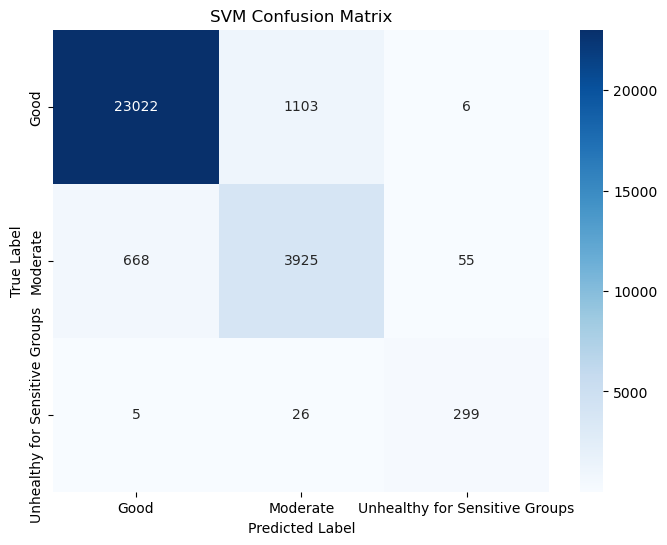

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

# Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('SVM Confusion Matrix')
plt.show()